# Upgraded Phase 3 Architecture A v3 — Portable Multi-Head Router (Leak Fixed)

This notebook builds, cross-validates, and exports the upgraded router model, strictly aligned with the **Prompt Profiling Complexity Tier Framework** guidelines.

### Major Updates:
1. **Leak-Free Automated Domain Classifier (Fixed Index Shift)** — corrected the feature index slicing range. By dynamically calculating index boundaries, we prevent domain dummy variables from leaking into the domain classifier (which previously caused artificial 100% training metrics).
2. **Strict Dimension-Derived Tier Routing** — predicts the five dimensions ($D1-D5$) and derives the final tier using the official weighted composite score formula.
3. **Higher Capacity D1 & D2 Classifiers** — increased the max depth (`max_depth=5`) for D1 and D2 heads to resolve complex semantic patterns and boost prediction recall.
4. **Expected Value Dimension Mapping** — replaced the ordinal binary threshold models with single **5-class multi-class XGBoost Classifiers** for each of the five dimensions.
5. **Portable Model Export** — exports XGBoost booster heads using portable JSON bytes (`save_raw(format='json')`) inside the standard `.pkl` bundle to guarantee forward/backward compatibility.

In [9]:
# Colab setup
!pip install -q xgboost sentence-transformers scikit-learn pandas numpy

In [10]:
import os
import ast
import json
import re
import warnings
import pickle
from pathlib import Path

import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
N_SPLITS = 7
PCA_COMPONENTS = 80


## Load Cleaned Dataset
Upload the repaired and balanced dataset file `final_dataset_rescored.csv` to Google Colab before running this cell.

In [11]:
DATA_PATH = '/content/final_dataset_rescored.csv'

if not os.path.exists(DATA_PATH):
    DATA_PATH = 'final_dataset_rescored.csv'

df = pd.read_csv(DATA_PATH)
print("Loaded dataset shape:", df.shape)
df.head()


Loaded dataset shape: (3673, 17)


,id,prompt,domain,tier,complexity,complexity_score,intent,task_type,reasoning_chain_detected,phrasing_style,d1,d2,d3,d4,d5,research_signals,confidence
0,id_0,Imagine you are a science fiction author renow...,General Knowledge,T2,medium,0.5125,SYNTHETIC,generation,True,NaN,0.75,0.50,0.75,0.0,0.0,[],0.8
1,id_1,You are an expert photography tutor. I want to...,Programming,T2,medium,0.4250,ANALYTICAL,generation,True,NaN,0.50,0.75,0.50,0.0,0.0,[],0.8
2,id_2,You are a leading neuroscientist specializing ...,Artificial Intelligence,T2,medium,0.6375,ANALYTICAL,reasoning,True,NaN,0.75,0.75,0.75,0.5,0.0,"[""scientific""]",0.9
3,id_3,I want to understand the basic human emotions....,General Knowledge,T1,low,0.2875,FACTUAL,generation,False,NaN,0.25,0.50,0.50,0.0,0.0,[],0.95
4,id_4,Here are examples of competitive exclusion. Ex...,Biology,T2,medium,0.5125,ANALYTICAL,reasoning,True,NaN,0.75,0.50,0.50,0.0,0.5,[],0.8


## Dataset Validation & Cleanup

In [12]:
SCORE_COLS = ['d1', 'd2', 'd3', 'd4', 'd5']
VALID_SCORES = [0.0, 0.25, 0.5, 0.75, 1.0]
SCORE_TO_CLASS = {score: idx for idx, score in enumerate(VALID_SCORES)}
CLASS_TO_SCORE = {idx: score for score, idx in SCORE_TO_CLASS.items()}

DIMENSION_LABELS = {
    'd1': 'Semantic Complexity',
    'd2': 'Domain Specificity',
    'd3': 'Output Formality',
    'd4': 'Research Dependency',
    'd5': 'Context Requirement',
}

D1_TO_INTENT = {
    0.00: 'FACTUAL',
    0.25: 'FACTUAL',
    0.50: 'ANALYTICAL',
    0.75: 'SYNTHETIC',
    1.00: 'STRATEGIC',
}

def normalize_bool(value):
    if isinstance(value, bool):
        return value
    if pd.isna(value):
        return False
    return str(value).strip().lower() == 'true'

def complexity_score_from_dims_frame(frame):
    return (
        frame['d1'] * 0.35 +
        frame['d2'] * 0.20 +
        frame['d3'] * 0.20 +
        frame['d4'] * 0.15 +
        frame['d5'] * 0.10
    )

def tier_from_score(score):
    if score < 0.40:
        return 'T1'
    if score < 0.70:
        return 'T2'
    return 'T3'

# --- Clean / align target features ---
df['expected_intent'] = df['d1'].map(D1_TO_INTENT)
misaligned_count = int((df['intent'] != df['expected_intent']).sum())
if misaligned_count > 0:
    print(f'Fixing {misaligned_count} D1<->intent misalignments')
    df['intent'] = df['expected_intent']
df.drop(columns=['expected_intent'], inplace=True)

# Merge formatting and sparql_generation to generation
df.loc[df['task_type'] == 'formatting', 'task_type'] = 'generation'
df.loc[df['task_type'] == 'sparql_generation', 'task_type'] = 'generation'

# Map rare task types with < 5 prompts to generation to prevent stratification errors
task_counts = df['task_type'].value_counts()
rare_tasks = task_counts[task_counts < 5].index
df.loc[df['task_type'].isin(rare_tasks), 'task_type'] = 'generation'

df['reasoning_chain_detected'] = df['reasoning_chain_detected'].apply(normalize_bool)
df['computed_complexity_score'] = complexity_score_from_dims_frame(df)
df['computed_tier'] = df['computed_complexity_score'].apply(tier_from_score)

print(f'Final rows: {len(df)}')
print(f'Tier counts: {df["tier"].value_counts().sort_index().to_dict()}')


Fixing 1105 D1<->intent misalignments
Final rows: 3673
Tier counts: {'T1': 1282, 'T2': 1525, 'T3': 866}


## 74 Hand-Crafted & Domain Features (Rubric Aligned)

In [13]:
ARTIFACT_TERMS = ['csv', 'json', 'pdf', 'log', 'yaml', 'yml', 'xlsx', 'docx', 'transcript', 'diagram']
CLOUD_PROVIDERS = ['aws', 'azure', 'gcp', 'google cloud', 'oci']
SYSTEMS = ['salesforce', 'servicenow', 'jira', 'workday', 'sap', 'snowflake', 'databricks', 'okta', 'hubspot', 'github', 'gitlab']
FRAMEWORKS = ['itil', 'finops', 'togaf', 'owasp', 'dora', 'nist', 'hipaa', 'soc 2', 'soc2', 'gdpr', 'iso 27001', 'pci-dss', 'pci dss']
VENDOR_TOOLS = sorted(set(CLOUD_PROVIDERS + SYSTEMS + ['openai', 'anthropic', 'bedrock', 'terraform', 'kubernetes', 'docker', 'jenkins', 'splunk']))

DOMAIN_BUCKETS = {
    'cloud': ['aws', 'azure', 'gcp', 'cloud', 'kubernetes', 'terraform'],
    'finops': ['finops', 'cost', 'budget', 'chargeback', 'showback'],
    'security': ['security', 'vulnerability', 'iam', 'zero trust', 'soc'],
    'devops': ['devops', 'ci/cd', 'pipeline', 'sre', 'deployment'],
    'data': ['data pipeline', 'etl', 'warehouse', 'lakehouse', 'spark'],
    'ai': ['ai', 'llm', 'genai', 'machine learning', 'model'],
    'hr': ['hr', 'employee', 'talent', 'workforce', 'recruiting'],
    'supply': ['supply chain', 'inventory', 'procurement', 'logistics'],
}

D1_COMPLEXITY_TERMS = [
    'strategic', 'cross-domain', 'enterprise-wide', 'synthesize', 'multi-cloud',
    'governance', 'architecture', 'framework', 'transformation', 'lifecycle',
    'holistic', 'end-to-end', 'migration', 'orchestration',
]

SIMPLE_FACTUAL_PATTERNS = [
    r'^what is\b', r'^define\b', r'^who is\b', r'^when\b',
    r'^list\b', r'^name\b', r'\bwhat does .{1,30} mean\b',
]

D2_DOMAIN_TERMS = [
    'kubernetes', 'terraform', 'sagemaker', 'databricks', 'snowflake',
    'cicd', 'ci/cd', 'finops', 'mlops', 'devsecops', 'apigee',
    'oauth', 'saml', 'oidc', 'vpc', 'subnet', 'iam',
]

def count_terms_safe(text, terms):
    return sum(1 for term in terms if term in text)

def any_terms_safe(text, terms):
    return any(term in text for term in terms)

def get_style_at(phrasing_styles, i):
    if phrasing_styles is None:
        return None
    try:
        value = phrasing_styles.iloc[i]
    except AttributeError:
        value = phrasing_styles[i]
    return None if pd.isna(value) else str(value).strip().lower()

def handcrafted_features(prompts, phrasing_styles=None, domains=None):
    rows = []
    for i, prompt in enumerate(prompts):
        text = str(prompt)
        lower = text.lower()
        words = re.findall(r'\b\w+\b', lower)
        unique_words = set(words)
        sentences = [s for s in re.split(r'[.!?]+', text) if s.strip()]
        lines = [line for line in text.splitlines() if line.strip()]
        style = get_style_at(phrasing_styles, i)

        row = {}
        row['char_len'] = len(text)
        row['word_count'] = len(words)
        row['sentence_count'] = max(1, len(sentences))
        row['avg_word_len'] = float(np.mean([len(w) for w in words])) if words else 0.0
        row['unique_word_ratio'] = len(unique_words) / max(1, len(words))
        row['line_count'] = len(lines)

        # PDF D5 Aligned Token buckets
        estimated_tokens = len(words) * 1.3
        row['token_bracket_factual'] = int(estimated_tokens < 1000)
        row['token_bracket_short'] = int(1000 <= estimated_tokens < 4000)
        row['token_bracket_medium'] = int(4000 <= estimated_tokens < 16000)
        row['token_bracket_long'] = int(16000 <= estimated_tokens < 32000)
        row['token_bracket_extreme'] = int(estimated_tokens >= 32000)

        # PDF D4 Aligned retrieval / live keywords
        row['live_retrieval_request'] = int(any_terms_safe(lower, ['real-time', 'live pricing', 'fetch latest', 'api call', 'lookup online', 'search the web', 'browse the web', 'current status']))
        row['has_attachment'] = int(any_terms_safe(lower, ['uploaded', 'attached', 'provided file', 'document below', 'context below', 'see below']))
        row['provided_artifact_count'] = count_terms_safe(lower, ARTIFACT_TERMS)
        row['large_context_signal'] = int(any_terms_safe(lower, ['across all', 'entire', 'all of our', 'company-wide', 'large context', 'full document']))
        row['multi_document_signal'] = int(any_terms_safe(lower, ['multiple', 'all the', 'each of the', 'various', 'several documents', 'set of files']))

        # PDF D3 Aligned Output Formality
        row['has_formal_deliverable'] = int(any_terms_safe(lower, ['report', 'brief', 'proposal', 'specification', 'whitepaper', 'requirements doc']))
        row['has_report_package'] = int(any_terms_safe(lower, ['appendix', 'table of contents', 'toc', 'risk register', 'executive summary', 'roadmap', 'implementation plan']))
        row['has_long_output_signal'] = int(any_terms_safe(lower, ['comprehensive', 'detailed', 'thorough', 'in-depth', 'end-to-end']))
        row['structured_section_count'] = count_terms_safe(lower, ['executive summary', 'timeline', 'roadmap', 'risk register', 'assumptions', 'recommendations', 'next steps', 'success metrics'])

        row['has_scope_words'] = int(any_terms_safe(lower, ['strategic', 'cross-domain', 'enterprise-wide', 'synthesize', 'multi-cloud', 'governance']))
        row['action_verb_count'] = count_terms_safe(lower, ['build', 'design', 'evaluate', 'integrate', 'optimize', 'develop', 'assess', 'recommend', 'compare'])
        row['multi_stage_signal'] = int(bool(re.search(r'\bphase\b|\bstage\b|\bstep\s*1\b|\bmilestone\b|\bsequentially\b|\bfirst\b.*\bthen\b', lower)))

        row['has_compliance'] = int(any_terms_safe(lower, ['nist', 'hipaa', 'soc2', 'soc 2', 'gdpr', 'iso 27001', 'pci-dss', 'pci dss', 'compliance']))
        row['cloud_providers_mentioned'] = count_terms_safe(lower, CLOUD_PROVIDERS)
        row['systems_mentioned'] = count_terms_safe(lower, SYSTEMS)
        row['domain_framework_count'] = count_terms_safe(lower, FRAMEWORKS)

        row['external_data_score'] = count_terms_safe(lower, ['market research', 'industry report', 'analyst', 'third-party', 'external data', 'latest', 'current'])
        row['has_time_reference'] = int(bool(re.search(r'\b20\d{2}\b|\bfy\d{2}|\bthis quarter\b|\blatest\b|\bcurrent\b|\brecent\b|\btoday\b|\bnow\b', lower)))
        row['vendor_tool_count'] = count_terms_safe(lower, VENDOR_TOOLS)
        row['has_market_terms'] = int(any_terms_safe(lower, ['competitor', 'market share', 'tam', 'sam', 'som', 'benchmark', 'industry trend']))
        row['has_cost_comparison'] = int(any_terms_safe(lower, ['pricing', 'tco', 'roi', 'showback', 'chargeback', 'cheapest']) or 'cost analysis' in lower)

        row['has_comparison'] = int(any_terms_safe(lower, ['compare', 'versus', 'tradeoff']) or any(phrase in lower for phrase in [' vs ', 'difference between']))
        row['stakeholder_mentions'] = count_terms_safe(lower, ['ceo', 'cto', 'cio', 'cfo', 'board', 'leadership', 'management', 'executive'])
        row['risk_language'] = count_terms_safe(lower, ['risk', 'threat', 'vulnerability', 'mitigation', 'breach', 'exposure', 'audit'])

        row['has_role_prompt'] = int(bool(re.search(r'\byou are\b|\bact as\b|\bassume the role\b', lower)))
        row['has_step_request'] = int(bool(re.search(r'\bstep[- ]by[- ]step\b|\bfirst\b.*\bthen\b|\bsequentially\b', lower)))
        row['has_chain_of_thought'] = int(bool(re.search(r'\bthink through\b|\breason about\b|\blet.s think\b|\bchain of thought\b|\bwalk me through\b', lower)))
        if '?' not in text:
            row['question_complexity'] = 0
        elif any(phrase in lower for phrase in ['what should', 'design a']) or any_terms_safe(lower, ['recommend', 'propose', 'strategy']):
            row['question_complexity'] = 3
        elif any_terms_safe(lower, ['why', 'how', 'compare', 'analyze', 'evaluate', 'assess']):
            row['question_complexity'] = 2
        else:
            row['question_complexity'] = 1
        row['multi_domain_count'] = sum(1 for bucket_terms in DOMAIN_BUCKETS.values() if any_terms_safe(lower, bucket_terms))

        row['has_code_block'] = int('```' in text)
        row['has_output_format'] = int(bool(re.search(r'\bin json\b|\bas a table\b|\bformat as\b|\bcsv output\b|\bin yaml\b|\bas a table\b|\bas markdown\b|\bstrict yaml\b|\bstrict json\b', lower)))
        row['has_creative_language'] = int(any_terms_safe(lower, ['imagine', 'creative', 'story', 'compose', 'fictional']) or 'write a' in lower)
        row['has_classification_request'] = int(any_terms_safe(lower, ['classify', 'categorize', 'label']) or any(phrase in lower for phrase in ['which category', 'sort into']))
        row['enumeration_signal'] = int(bool(re.search(r'\blist\b|\btop \d+\b|\benumerate\b|\bbullet point\b|\brank\b', lower)))

        row['d1_strategic_signal_count'] = count_terms_safe(lower, D1_COMPLEXITY_TERMS)
        row['d1_simple_factual_signal'] = int(any(re.search(pattern, lower) for pattern in SIMPLE_FACTUAL_PATTERNS))
        row['d1_multi_constraint_count'] = count_terms_safe(lower, ['include', 'cover', 'consider', 'account for', 'must'])
        row['d1_solution_design_signal'] = int(any_terms_safe(lower, ['design', 'architect', 'plan', 'strategy', 'roadmap']))
        row['d2_domain_term_count'] = count_terms_safe(lower, D2_DOMAIN_TERMS)
        row['d2_acronym_count'] = len(re.findall(r'\b[A-Z]{2,6}\b', text))
        row['d2_vendor_or_framework_signal'] = int(row['vendor_tool_count'] > 0 or row['domain_framework_count'] > 0)
        row['d2_generic_prompt_signal'] = int(row['d2_domain_term_count'] == 0 and row['cloud_providers_mentioned'] == 0 and row['systems_mentioned'] == 0)

        row['phrasing_explicit'] = int(style == 'explicit')
        row['phrasing_implicit'] = int(style == 'implicit')
        row['phrasing_vague'] = int(style == 'vague')

        rows.append(row)

    feature_df = pd.DataFrame(rows).fillna(0)

    VALID_DOMAINS = [
        "Artificial Intelligence", "Biology", "Business", "Cloud Computing",
        "Cybersecurity", "Data Science", "Deep Learning", "DevOps",
        "Digital Transformation", "Education", "Embedded Systems", "FinOps",
        "Finance", "General Knowledge", "Human Resources", "Legal",
        "Machine Learning", "Marketing", "Mathematics", "Natural Language Processing",
        "Programming", "Software Engineering", "Statistics", "Supply Chain"
    ]

    if domains is not None:
        domains_categorical = pd.Categorical(domains, categories=VALID_DOMAINS)
        df_dom = pd.get_dummies(domains_categorical, prefix='dom', dtype=int)
        feature_df = pd.concat([feature_df, df_dom.reset_index(drop=True)], axis=1)
    else:
        for dom in VALID_DOMAINS:
            feature_df[f'dom_{dom}'] = 0

    return feature_df

hand_df = handcrafted_features(df['prompt'], df.get('phrasing_style'), df.get('domain'))
print('Handcrafted features shape:', hand_df.shape)


Handcrafted features shape: (3673, 80)


## Embeddings — BGE-base-en-v1.5

In [8]:
EMBEDDING_MODEL_NAME = 'BAAI/bge-base-en-v1.5'
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

prompts = df['prompt'].astype(str).tolist()
prompts_for_encoding = ['Represent this sentence: ' + p for p in prompts]

print("Encoding dataset prompts...")
embeddings = embedding_model.encode(
    prompts_for_encoding,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True,
)

print('Embedding shape:', embeddings.shape)


HTTP Error 504 thrown while requesting HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/./modules.json
Retrying in 2s [Retry 2/5].
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/./modules.json
Retrying in 4s [Retry 3/5].
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/./modules.json
Retrying in 8s [Retry 4/5].
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/./modules.json
Retrying in 8s [Retry 5/5].


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding dataset prompts...


Batches:   0%|          | 0/115 [00:00<?, ?it/s]

Embedding shape: (3673, 768)


## Nearest-Neighbors Cosine Feature Helper

In [14]:
def construct_nn_features(embeddings_part, knn_model, train_df, is_train=False):
    distances, indices = knn_model.kneighbors(embeddings_part)
    if is_train:
        indices = indices[:, 1:]
        distances = distances[:, 1:]
    else:
        indices = indices[:, :-1]
        distances = distances[:, :-1]

    train_tier_numeric = np.array([{'T1': 0, 'T2': 1, 'T3': 2}[t] for t in train_df['tier'].values])
    train_d1 = train_df['d1'].values
    train_d2 = train_df['d2'].values

    feats = []
    for i in range(len(indices)):
        idxs = indices[i]
        dists = distances[i]
        feats.append([
            train_tier_numeric[idxs].mean(),
            train_tier_numeric[idxs].std(),
            train_d1[idxs].mean(),
            train_d1[idxs].std(),
            train_d2[idxs].mean(),
            train_d2[idxs].std(),
            dists.mean(),
        ])
    return np.array(feats)


## Feature Matrix Helpers with KNN Pipeline

In [15]:
def fit_shared_transformers(train_embeddings, train_hand_features, train_df):
    pca = PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_STATE)
    train_emb_pca = pca.fit_transform(train_embeddings)

    knn_model = NearestNeighbors(n_neighbors=6, metric='cosine')
    knn_model.fit(train_embeddings)
    train_knn_feats = construct_nn_features(train_embeddings, knn_model, train_df, is_train=True)

    train_raw = np.hstack([train_emb_pca, train_hand_features, train_knn_feats])
    scaler = StandardScaler()
    train_X = scaler.fit_transform(train_raw)
    return pca, scaler, knn_model, train_X

def transform_shared_features(embeddings_part, hand_features_part, pca, scaler, knn_model, train_df):
    emb_pca = pca.transform(embeddings_part)
    knn_feats = construct_nn_features(embeddings_part, knn_model, train_df, is_train=False)
    raw = np.hstack([emb_pca, hand_features_part, knn_feats])
    return scaler.transform(raw)

def fit_full_feature_matrix():
    pca, scaler, knn_model, X_full = fit_shared_transformers(embeddings, hand_df.values, df)
    print('PCA variance explained:', round(float(pca.explained_variance_ratio_.sum()), 4))
    print('Feature shape:', X_full.shape)
    return pca, scaler, knn_model, X_full


## Target Label Encoding

In [16]:
label_encoders = {}
targets = {}

for col in SCORE_COLS:
    targets[col] = df[col].astype(float).map(SCORE_TO_CLASS).astype(int).values

for col in ['intent', 'task_type']:
    le = LabelEncoder()
    targets[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f'{col}: {list(le.classes_)}')

# Encode domain categories for the automated predictor
dom_le = LabelEncoder()
targets['domain'] = dom_le.fit_transform(df['domain'].astype(str))
label_encoders['domain'] = dom_le

targets['reasoning_chain_detected'] = df['reasoning_chain_detected'].astype(bool).astype(int).values

tier_le = LabelEncoder()
tier_le.fit(['T1', 'T2', 'T3'])
label_encoders['tier'] = tier_le
tier_true_encoded = tier_le.transform(df['tier'].values)

head_classes = {
    'intent': len(label_encoders['intent'].classes_),
    'task_type': len(label_encoders['task_type'].classes_),
    'domain': len(label_encoders['domain'].classes_),
    'reasoning_chain_detected': 2,
    'd1': 5,
    'd2': 5,
    'd3': 5,
    'd4': 5,
    'd5': 5,
}
print('Standard heads:', list(head_classes.keys()))


intent: ['ANALYTICAL', 'FACTUAL', 'STRATEGIC', 'SYNTHETIC']
task_type: ['classification', 'code_writing', 'coding', 'comparison', 'debugging', 'explanation', 'generation', 'optimization', 'reasoning', 'summarisation', 'system_design']
Standard heads: ['intent', 'task_type', 'domain', 'reasoning_chain_detected', 'd1', 'd2', 'd3', 'd4', 'd5']


## Model Helpers — 5-Class Multiclass Dimension Heads

In [17]:
def make_xgb(num_classes, seed=RANDOM_STATE, is_dimension=False):
    is_binary = num_classes == 2
    max_depth = 5 if is_dimension else 3
    colsample = 0.70 if is_dimension else 0.88

    params = dict(
        n_estimators=450 if is_dimension else 350,
        max_depth=max_depth,
        learning_rate=0.04 if is_dimension else 0.045,
        subsample=0.88,
        colsample_bytree=colsample,
        reg_lambda=2.5,
        min_child_weight=5,
        random_state=seed,
        eval_metric='logloss' if is_binary else 'mlogloss',
        objective='binary:logistic' if is_binary else 'multi:softprob',
        tree_method='hist',
    )
    if not is_binary:
        params['num_class'] = num_classes
    return XGBClassifier(**params)

def capped_sample_weight(y, cap=3.0):
    weights = compute_sample_weight(class_weight='balanced', y=y)
    return np.clip(weights, 1.0 / cap, cap)

WEIGHT_CAPS = {
    'intent': 3.0,
    'task_type': 2.5,
    'domain': 2.0,
    'reasoning_chain_detected': 2.0,
    'd1': 2.0,
    'd2': 2.0,
    'd3': 2.0,
    'd4': 2.0,
    'd5': 2.0,
}

def fit_head(name, X_train, y_train, seed=RANDOM_STATE):
    is_dim = (name in SCORE_COLS)
    model = make_xgb(head_classes[name], seed=seed, is_dimension=is_dim)
    sw = capped_sample_weight(y_train, cap=WEIGHT_CAPS.get(name, 3.0))
    model.fit(X_train, y_train, sample_weight=sw)
    return model

def train_all_heads(X_train, train_idx, seed=RANDOM_STATE):
    heads = {}

    # 1. Train the domain classifier (using features without dummy columns to prevent leak)
    # PCA components (80) + Handcrafted features (50) = 130 features. Domain dummies start at 130.
    # Correct indices to prevent leak: indices 0 to 129 + indices 154 to end (KNN features).
    domain_feat_indices = list(range(130)) + list(range(154, X_train.shape[1]))
    X_train_domain = X_train[:, domain_feat_indices]
    heads['domain'] = make_xgb(head_classes['domain'], seed=seed)
    sw_domain = capped_sample_weight(targets['domain'][train_idx], cap=2.0)
    heads['domain'].fit(X_train_domain, targets['domain'][train_idx], sample_weight=sw_domain)

    # 2. Train other classification heads (using all features)
    for name in ['intent', 'task_type', 'reasoning_chain_detected']:
        y_train = targets[name][train_idx]
        heads[name] = fit_head(name, X_train, y_train, seed=seed)

    # 3. Train 5-Class Multiclass Dimension Heads directly
    for col in SCORE_COLS:
        y_train = targets[col][train_idx]
        heads[col] = fit_head(col, X_train, y_train, seed=seed)
    return heads


## 5-Fold Stratified Cross-Validation

In [18]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
ALL_HEADS = ['domain', 'intent', 'task_type', 'reasoning_chain_detected'] + SCORE_COLS

fold_results = {name: {'accuracy': [], 'macro_f1': []} for name in ALL_HEADS + ['derived_tier']}
oof_true = {name: [] for name in ALL_HEADS + ['derived_tier']}
oof_pred = {name: [] for name in ALL_HEADS + ['derived_tier']}

for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['tier']), start=1):
    print(f'\n=== Fold {fold}/{N_SPLITS} ===')

    fold_pca, fold_scaler, fold_knn, X_train = fit_shared_transformers(
        embeddings[train_idx], hand_df.iloc[train_idx].values, df.iloc[train_idx]
    )
    X_val = transform_shared_features(
        embeddings[val_idx], hand_df.iloc[val_idx].values, fold_pca, fold_scaler, fold_knn, df.iloc[train_idx]
    )

    heads = train_all_heads(X_train, train_idx, seed=RANDOM_STATE + fold)

    # Domain classifier head prediction (Leak Fixed Index Slicing)
    domain_feat_indices = list(range(130)) + list(range(154, X_val.shape[1]))
    y_true_dom = targets['domain'][val_idx]
    y_pred_dom = heads['domain'].predict(X_val[:, domain_feat_indices])
    fold_results['domain']['accuracy'].append(accuracy_score(y_true_dom, y_pred_dom))
    fold_results['domain']['macro_f1'].append(f1_score(y_true_dom, y_pred_dom, average='macro', zero_division=0))
    oof_true['domain'].extend(y_true_dom.tolist())
    oof_pred['domain'].extend(y_pred_dom.tolist())

    # Standard heads
    for name in ['intent', 'task_type', 'reasoning_chain_detected']:
        y_true = targets[name][val_idx]
        y_pred = heads[name].predict(X_val)
        fold_results[name]['accuracy'].append(accuracy_score(y_true, y_pred))
        fold_results[name]['macro_f1'].append(f1_score(y_true, y_pred, average='macro', zero_division=0))
        oof_true[name].extend(y_true.tolist())
        oof_pred[name].extend(y_pred.tolist())

    # Dimensions
    expected_dims = {}
    for col in SCORE_COLS:
        y_true = targets[col][val_idx]
        probas = heads[col].predict_proba(X_val)
        y_pred = np.argmax(probas, axis=1)

        fold_results[col]['accuracy'].append(accuracy_score(y_true, y_pred))
        fold_results[col]['macro_f1'].append(f1_score(y_true, y_pred, average='macro', zero_division=0))
        oof_true[col].extend(y_true.tolist())
        oof_pred[col].extend(y_pred.tolist())

        expected_dims[col] = probas @ np.array(VALID_SCORES)

    # Chained continuous complexity derived tier
    pred_scores = pd.DataFrame(expected_dims)
    complexity_scores = complexity_score_from_dims_frame(pred_scores)
    derived_tier_labels = complexity_scores.apply(tier_from_score).values
    y_true_tier = tier_true_encoded[val_idx]
    derived_tier_encoded = tier_le.transform(derived_tier_labels)

    fold_results['derived_tier']['accuracy'].append(accuracy_score(y_true_tier, derived_tier_encoded))
    fold_results['derived_tier']['macro_f1'].append(f1_score(y_true_tier, derived_tier_encoded, average='macro', zero_division=0))
    oof_true['derived_tier'].extend(y_true_tier.tolist())
    oof_pred['derived_tier'].extend(derived_tier_encoded.tolist())

    print(f'Fold {fold} | Domain Acc: {fold_results["domain"]["accuracy"][-1]:.4f} | Derived Tier Acc: {fold_results["derived_tier"]["accuracy"][-1]:.4f}')

# Summary printouts
print('\n' + '=' * 72)
print('7-Fold CV Evaluation Metrics (mean +/- std)')
print('=' * 72)
for name in ALL_HEADS + ['derived_tier']:
    acc = np.array(fold_results[name]['accuracy'])
    f1 = np.array(fold_results[name]['macro_f1'])
    print(f'{name:30s} Acc: {acc.mean():.4f} +/- {acc.std():.4f}   F1: {f1.mean():.4f} +/- {f1.std():.4f}')



=== Fold 1/7 ===
Fold 1 | Domain Acc: 0.7524 | Derived Tier Acc: 0.8457

=== Fold 2/7 ===
Fold 2 | Domain Acc: 0.7695 | Derived Tier Acc: 0.8190

=== Fold 3/7 ===
Fold 3 | Domain Acc: 0.7829 | Derived Tier Acc: 0.8400

=== Fold 4/7 ===
Fold 4 | Domain Acc: 0.7448 | Derived Tier Acc: 0.8362

=== Fold 5/7 ===
Fold 5 | Domain Acc: 0.7371 | Derived Tier Acc: 0.8171

=== Fold 6/7 ===
Fold 6 | Domain Acc: 0.7634 | Derived Tier Acc: 0.8034

=== Fold 7/7 ===
Fold 7 | Domain Acc: 0.7481 | Derived Tier Acc: 0.8225

7-Fold CV Evaluation Metrics (mean +/- std)
domain                         Acc: 0.7569 +/- 0.0147   F1: 0.7828 +/- 0.0229
intent                         Acc: 0.7580 +/- 0.0160   F1: 0.7302 +/- 0.0130
task_type                      Acc: 0.7982 +/- 0.0159   F1: 0.4501 +/- 0.0854
reasoning_chain_detected       Acc: 0.9216 +/- 0.0097   F1: 0.8908 +/- 0.0135
d1                             Acc: 0.7574 +/- 0.0182   F1: 0.7234 +/- 0.0244
d2                             Acc: 0.7732 +/- 0.0092 

### Detailed Classification Reports

In [19]:
print('\nDerived Tier Classification Report (Dimension-derived continuous routing):')
print(classification_report(oof_true['derived_tier'], oof_pred['derived_tier'], target_names=tier_le.classes_, zero_division=0))

print('\nDomain Predictor Classification Report:')
print(classification_report(oof_true['domain'], oof_pred['domain'], target_names=dom_le.classes_, zero_division=0))



Derived Tier Classification Report (Dimension-derived continuous routing):
              precision    recall  f1-score   support

          T1       0.83      0.84      0.83      1282
          T2       0.77      0.83      0.80      1525
          T3       0.94      0.80      0.86       866

    accuracy                           0.83      3673
   macro avg       0.85      0.82      0.83      3673
weighted avg       0.83      0.83      0.83      3673


Domain Predictor Classification Report:
                             precision    recall  f1-score   support

    Artificial Intelligence       0.78      0.73      0.76       341
                    Biology       0.77      0.74      0.75       319
                   Business       0.50      0.50      0.50       224
            Cloud Computing       0.70      0.66      0.68        99
              Cybersecurity       0.79      0.80      0.79       196
               Data Science       0.68      0.68      0.68       111
              Deep

## Final Full-Dataset Training

In [20]:
print("Training final models on complete dataset features...")
final_pca, final_scaler, final_knn_model, X_full = fit_full_feature_matrix()
final_train_idx = np.arange(len(df))
heads = train_all_heads(X_full, final_train_idx, seed=RANDOM_STATE)
print('All target models successfully trained:', list(heads.keys()))


Training final models on complete dataset features...
PCA variance explained: 0.6506
Feature shape: (3673, 167)
All target models successfully trained: ['domain', 'intent', 'task_type', 'reasoning_chain_detected', 'd1', 'd2', 'd3', 'd4', 'd5']


## Rule-Based Research Signals

In [21]:
RESEARCH_SIGNAL_KEYWORDS = {
    'market_research': ['market', 'industry', 'trend', 'tam', 'sam', 'som'],
    'competitive_analysis': ['competitor', 'competitive', 'benchmark', 'rival'],
    'regulatory_compliance': ['regulation', 'regulatory', 'compliance', 'gdpr', 'hipaa', 'sox', 'eu ai act'],
    'security': ['security', 'vulnerability', 'threat', 'risk', 'iam', 'zero trust'],
    'cloud_infrastructure': ['aws', 'azure', 'gcp', 'cloud', 'kubernetes', 'terraform'],
    'finops': ['finops', 'cost', 'spend', 'budget', 'showback', 'chargeback'],
    'devops': ['ci/cd', 'pipeline', 'deployment', 'sre', 'devops', 'observability'],
    'data_engineering': ['data pipeline', 'etl', 'warehouse', 'lakehouse', 'spark'],
    'ai_governance': ['ai governance', 'llm', 'model risk', 'genai', 'guardrail'],
    'system_integration': ['integration', 'api', 'webhook', 'middleware'],
    'supply_chain': ['supply chain', 'inventory', 'procurement', 'logistics'],
    'hr_tech': ['hr', 'employee', 'talent', 'workforce', 'recruiting'],
    'vendor_analysis': ['vendor', 'rfi', 'rfp', 'procurement'],
}

def extract_research_signals(prompt, d4_score):
    if d4_score <= 0:
        return []
    text = str(prompt).lower()
    signals = []
    for signal, keywords in RESEARCH_SIGNAL_KEYWORDS.items():
        if any(keyword in text for keyword in keywords):
            signals.append(signal)
    return signals if signals else ['external_research']


## Unified Inference Function with Automated Domain Prediction

In [22]:
train_df_subset = df[['tier', 'd1', 'd2']].copy()

def build_features_for_prompts(new_prompts, new_domains=None):
    new_prompts_str = [str(p) for p in new_prompts]
    prefixed = ['Represent this sentence: ' + p for p in new_prompts_str]
    new_embeddings = embedding_model.encode(
        prefixed, batch_size=32, show_progress_bar=False, normalize_embeddings=True,
    )
    new_hand = handcrafted_features(new_prompts_str, phrasing_styles=None, domains=new_domains)
    return transform_shared_features(new_embeddings, new_hand.values, final_pca, final_scaler, final_knn_model, train_df_subset)

def predict_prompt(prompt, domain=None):
    # If no domain is provided, automatically predict it first
    if domain is None:
        X_one_temp = build_features_for_prompts([prompt], new_domains=None)
        # PCA components (80) + Handcrafted features (50) = 130 features. Domain dummies start at 130.
        # Exclude dummy columns (columns 130 to 153) for domain prediction
        domain_feat_indices = list(range(130)) + list(range(154, X_one_temp.shape[1]))
        X_one_domain = X_one_temp[:, domain_feat_indices]

        # Load serialized model if it is in bytes representation
        if isinstance(heads['domain'], (bytes, str)):
            from xgboost import XGBClassifier
            dom_model = XGBClassifier()
            dom_model.load_raw(heads['domain'])
            pred_dom_class = dom_model.predict(X_one_domain)[0]
        else:
            pred_dom_class = heads['domain'].predict(X_one_domain)[0]

        domain = label_encoders['domain'].inverse_transform([pred_dom_class])[0]

    X_one = build_features_for_prompts([prompt], new_domains=[domain])

    # Predict standard classification heads (loading JSON booster if needed)
    for name in ['intent', 'task_type', 'reasoning_chain_detected']:
        model_obj = heads[name]
        if isinstance(model_obj, (bytes, str)):
            from xgboost import XGBClassifier
            clf = XGBClassifier()
            clf.load_raw(model_obj)
        else:
            clf = model_obj

        if name == 'reasoning_chain_detected':
            reasoning_chain = bool(int(clf.predict(X_one)[0]))
        elif name == 'intent':
            intent = label_encoders['intent'].inverse_transform(clf.predict(X_one))[0]
        elif name == 'task_type':
            task_type = label_encoders['task_type'].inverse_transform(clf.predict(X_one))[0]

    # Predict D1-D5 expected values using 5-class probas
    predicted_dims = {}
    dim_confidences = []
    expected_scores = {}

    for col in SCORE_COLS:
        model_obj = heads[col]
        if isinstance(model_obj, (bytes, str)):
            from xgboost import XGBClassifier
            clf = XGBClassifier()
            clf.load_raw(model_obj)
        else:
            clf = model_obj

        probas = clf.predict_proba(X_one)
        pred_class = np.argmax(probas, axis=1)[0]
        predicted_dims[col] = VALID_SCORES[pred_class]
        dim_confidences.append(float(np.max(probas)))

        expected_scores[col] = float(probas @ np.array(VALID_SCORES))

    score = (
        expected_scores['d1'] * 0.35 +
        expected_scores['d2'] * 0.20 +
        expected_scores['d3'] * 0.20 +
        expected_scores['d4'] * 0.15 +
        expected_scores['d5'] * 0.10
    )
    derived_tier = tier_from_score(score)

    # Predict probabilities for standard heads to calculate confidence
    proba_sums = []
    for name in ['intent', 'task_type', 'reasoning_chain_detected']:
        model_obj = heads[name]
        if isinstance(model_obj, (bytes, str)):
            from xgboost import XGBClassifier
            clf = XGBClassifier()
            clf.load_raw(model_obj)
        else:
            clf = model_obj
        proba_sums.append(float(np.max(clf.predict_proba(X_one)[0])))

    key_confidences = dim_confidences + proba_sums
    confidence = float(np.mean(key_confidences))

    result = {}
    for col in SCORE_COLS:
        result[col] = predicted_dims[col]
        result[f'{col}_label'] = DIMENSION_LABELS[col]

    result.update({
        'domain': domain,
        'complexity_score': round(float(score), 4),
        'derived_tier': derived_tier,
        'intent': intent,
        'task_type': task_type,
        'reasoning_chain_detected': reasoning_chain,
        'research_signals': extract_research_signals(prompt, predicted_dims['d4']),
        'confidence': round(confidence, 4),
    })
    return result


## Score New Prompts from File

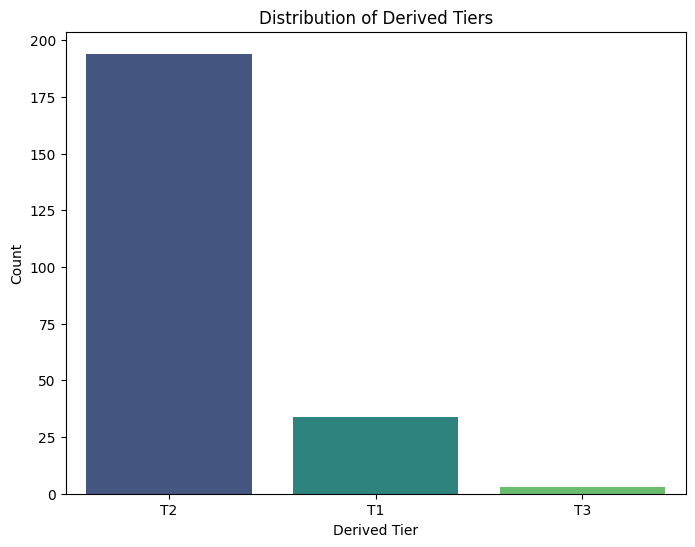

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(x='derived_tier', data=scored_prompts_df, palette='viridis', order=scored_prompts_df['derived_tier'].value_counts().index)
plt.title('Distribution of Derived Tiers')
plt.xlabel('Derived Tier')
plt.ylabel('Count')
plt.show()

## Testing Prompts with Models from Pickle File

In [34]:
import pickle
from xgboost import XGBClassifier

# Load the model bundle
MODEL_BUNDLE_PATH = '/content/phase3_v3_model_bundle.pkl'
with open(MODEL_BUNDLE_PATH, 'rb') as f:
    loaded_model_bundle = pickle.load(f)

# Re-assign global variables for predict_prompt to use the loaded models
final_pca = loaded_model_bundle['pca']
final_scaler = loaded_model_bundle['scaler']
final_knn_model = loaded_model_bundle['knn_model']
train_df_subset = loaded_model_bundle['train_df_subset']
heads = loaded_model_bundle['heads']
label_encoders = loaded_model_bundle['label_encoders']
CLASS_TO_SCORE = loaded_model_bundle['class_to_score'] # Ensure this is also available
DIMENSION_LABELS = loaded_model_bundle['dimension_labels'] # Ensure this is also available
VALID_SCORES = loaded_model_bundle['valid_scores'] # Ensure this is also available
SCORE_COLS = loaded_model_bundle['score_cols'] # Ensure this is also available

# The predict_prompt function needs to be re-evaluated as it depends on these globals.
# For safety and clarity, the function is copied here from its original definition cell
# If the function was modified, ensure this copy reflects the latest version.

# Definition of predict_prompt (re-copied for clarity and to ensure it has access to updated globals)
def build_features_for_prompts(new_prompts, new_domains=None):
    new_prompts_str = [str(p) for p in new_prompts]
    prefixed = ['Represent this sentence: ' + p for p in new_prompts_str]
    new_embeddings = embedding_model.encode(
        prefixed, batch_size=32, show_progress_bar=False, normalize_embeddings=True,
    )
    new_hand = handcrafted_features(new_prompts_str, phrasing_styles=None, domains=new_domains)
    return transform_shared_features(new_embeddings, new_hand.values, final_pca, final_scaler, final_knn_model, train_df_subset)

def predict_prompt(prompt, domain=None):
    # If no domain is provided, automatically predict it first
    if domain is None:
        X_one_temp = build_features_for_prompts([prompt], new_domains=None)
        # PCA components (80) + Handcrafted features (50) = 130 features. Domain dummies start at 130.
        # Exclude dummy columns (columns 130 to 153) for domain prediction
        domain_feat_indices = list(range(130)) + list(range(154, X_one_temp.shape[1]))
        X_one_domain = X_one_temp[:, domain_feat_indices]

        # Load serialized model if it is in bytes representation
        if isinstance(heads['domain'], (bytes, str)):
            from xgboost import XGBClassifier # Import locally to avoid issues if not already imported
            dom_model = XGBClassifier()
            dom_model.load_raw(heads['domain'])
            pred_dom_class = dom_model.predict(X_one_domain)[0]
        else:
            pred_dom_class = heads['domain'].predict(X_one_domain)[0]

        domain = label_encoders['domain'].inverse_transform([pred_dom_class])[0]

    X_one = build_features_for_prompts([prompt], new_domains=[domain])

    # Predict standard classification heads (loading JSON booster if needed)
    for name in ['intent', 'task_type', 'reasoning_chain_detected']:
        model_obj = heads[name]
        if isinstance(model_obj, (bytes, str)):
            from xgboost import XGBClassifier
            clf = XGBClassifier()
            clf.load_raw(model_obj)
        else:
            clf = model_obj

        if name == 'reasoning_chain_detected':
            reasoning_chain = bool(int(clf.predict(X_one)[0]))
        elif name == 'intent':
            intent = label_encoders['intent'].inverse_transform(clf.predict(X_one))[0]
        elif name == 'task_type':
            task_type = label_encoders['task_type'].inverse_transform(clf.predict(X_one))[0]

    # Predict D1-D5 expected values using 5-class probas
    predicted_dims = {}
    dim_confidences = []
    expected_scores = {}

    for col in SCORE_COLS:
        model_obj = heads[col]
        if isinstance(model_obj, (bytes, str)):
            from xgboost import XGBClassifier
            clf = XGBClassifier()
            clf.load_raw(model_obj)
        else:
            clf = model_obj

        probas = clf.predict_proba(X_one)
        pred_class = np.argmax(probas, axis=1)[0]
        predicted_dims[col] = VALID_SCORES[pred_class]
        dim_confidences.append(float(np.max(probas)))

        expected_scores[col] = float(probas @ np.array(VALID_SCORES))

    score = (
        expected_scores['d1'] * 0.35 +
        expected_scores['d2'] * 0.20 +
        expected_scores['d3'] * 0.20 +
        expected_scores['d4'] * 0.15 +
        expected_scores['d5'] * 0.10
    )
    derived_tier = tier_from_score(score)

    # Predict probabilities for standard heads to calculate confidence
    proba_sums = []
    for name in ['intent', 'task_type', 'reasoning_chain_detected']:
        model_obj = heads[name]
        if isinstance(model_obj, (bytes, str)):
            from xgboost import XGBClassifier
            clf = XGBClassifier()
            clf.load_raw(model_obj)
        else:
            clf = model_obj
        proba_sums.append(float(np.max(clf.predict_proba(X_one)[0])))

    key_confidences = dim_confidences + proba_sums
    confidence = float(np.mean(key_confidences))

    result = {}
    for col in SCORE_COLS:
        result[col] = predicted_dims[col]
        # result[f'{col}_label'] = DIMENSION_LABELS[col] # Exclude d*_label as requested

    result.update({
        'domain': domain,
        'complexity_score': round(float(score), 4),
        'derived_tier': derived_tier,
        'intent': intent,
        'task_type': task_type,
        'reasoning_chain_detected': reasoning_chain,
        'research_signals': extract_research_signals(prompt, predicted_dims['d4']),
        'confidence': round(confidence, 4),
    })
    return result

# Load the prompts from the CSV file
prompts_df_test = pd.read_csv('/content/prompts_231_raw.csv')

scored_prompts_test = []
for i, row in prompts_df_test.iterrows():
    prompt = row['prompt']
    result = predict_prompt(prompt)
    # Add the original 'prompt' column to the result dictionary
    result['prompt'] = prompt
    scored_prompts_test.append(result)

scored_prompts_df_test = pd.DataFrame(scored_prompts_test)

# Display the desired columns
display_columns = ['prompt', 'd1', 'd2', 'd3', 'd4', 'd5', 'derived_tier', 'domain', 'confidence']
display(scored_prompts_df_test[display_columns])

,prompt,d1,d2,d3,d4,d5,derived_tier,domain,confidence
0,\n\nVENDOR ENGAGEMENT COMPLIANCE POLICY (excer...,0.25,0.50,0.50,0.00,0.0,T2,Legal,0.5651
1,\n\nVENDOR ENGAGEMENT COMPLIANCE POLICY (excer...,0.75,0.75,0.50,0.00,0.0,T2,Legal,0.5624
2,\n\nVENDOR ENGAGEMENT COMPLIANCE POLICY (excer...,0.25,0.50,0.50,0.00,0.0,T2,Legal,0.5490
3,TASK: Draft a complete technical specification...,0.50,0.75,1.00,0.00,0.0,T2,Business,0.6256
4,TASK: Draft a complete technical specification...,0.50,0.75,1.00,0.00,0.0,T2,Business,0.6256
...,...,...,...,...,...,...,...,...,...
226,@prefix : <http://example.org/vendorrisk#> .\n...,0.25,0.50,1.00,0.75,0.0,T2,Artificial Intelligence,0.6370
227,@prefix : <http://example.org/vendorrisk#> .\n...,0.25,1.00,1.00,0.75,0.0,T2,Artificial Intelligence,0.6015
228,\n\nTASK: The data above is inconsistently for...,0.50,0.50,0.75,0.00,0.0,T2,Business,0.5842
229,\n\nTASK: The data above is inconsistently for...,0.50,0.50,0.75,0.00,0.0,T2,Data Science,0.6381


In [35]:
output_csv_path_test = '/content/scored_prompts_test.csv'
scored_prompts_df_test.to_csv(output_csv_path_test, index=False)

from google.colab import files
files.download(output_csv_path_test)
print(f'Downloaded scored prompts to {output_csv_path_test}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded scored prompts to /content/scored_prompts_test.csv


## Run Sample Inference Check

In [23]:
sample_prompt = 'Design a multi-cloud GenAI governance architecture for a Fortune 500 company, including compliance risks and vendor evaluation criteria.'

print("Automated prediction verification (no manual domain input):")
print(json.dumps(predict_prompt(sample_prompt), indent=2))


Automated prediction verification (no manual domain input):
{
  "d1": 0.75,
  "d1_label": "Semantic Complexity",
  "d2": 1.0,
  "d2_label": "Domain Specificity",
  "d3": 1.0,
  "d3_label": "Output Formality",
  "d4": 0.75,
  "d4_label": "Research Dependency",
  "d5": 0.0,
  "d5_label": "Context Requirement",
  "domain": "DevOps",
  "complexity_score": 0.7674,
  "derived_tier": "T3",
  "intent": "SYNTHETIC",
  "task_type": "reasoning",
  "reasoning_chain_detected": true,
  "research_signals": [
    "regulatory_compliance",
    "security",
    "cloud_infrastructure",
    "ai_governance",
    "vendor_analysis"
  ],
  "confidence": 0.7388
}


## Export Model Bundle File

In [24]:
from google.colab import files

MODEL_BUNDLE_PATH = '/content/phase3_v3_model_bundle.pkl'

model_bundle = {
    'embedding_model_name': EMBEDDING_MODEL_NAME,
    'embedding_query_prefix': 'Represent this sentence: ',
    'pca': final_pca,
    'scaler': final_scaler,
    'knn_model': final_knn_model,
    'train_df_subset': train_df_subset,
    'heads': heads,  # Save clean Python objects directly
    'label_encoders': label_encoders,
    'class_to_score': CLASS_TO_SCORE,
    'dimension_labels': DIMENSION_LABELS,
    'valid_scores': VALID_SCORES,
    'score_cols': SCORE_COLS,
    'architecture': 'single_stage_ordinal_knn_with_domain_classifier_automated_portable_v4',
}

with open(MODEL_BUNDLE_PATH, 'wb') as f:
    pickle.dump(model_bundle, f)

print(f'Saved model bundle to {MODEL_BUNDLE_PATH}')
files.download(MODEL_BUNDLE_PATH)


Saved model bundle to /content/phase3_v3_model_bundle.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>